# Analyse des déterminants de l'équipement en Véhicules Électriques

## 1. Introduction

Ce projet vise à comprendre quels facteurs (socio-économiques, infrastructures existantes) influencent le taux d'équipement en véhicules électriques au niveau communal en France.

Nous fusionnons trois sources de données provenant de data.gouv.fr :
- IRVE : Données sur les infrastructures de recharge.
- INSEE : Revenus et données socio-économiques.
- Immatriculations : Parc de VE par commune.

## 2. Chargement et Exploration des Données Brutes

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.loading import charger_communes
from src.cleaning import imputer_valeurs_manquantes_fusion, reparer_encodage_implantation, regrouper_implantation_station, standardize_all_codes, clean_irve_variables_finales, corriger_codes_incoherents, corriger_par_nom, corriger_conflit_code_postal, garder_derniere_observation_commune
from src.features import creer_features_irve, creer_taux_equipement_ve
from src.modelisation import modelisation_lasso, modelisation_xgboost
from src.utils import creer_gdf_irve, joindre_communes, ajouter_codes_geo
from src.loading import load_data_onyxia
from src.regression_lasso_function import regression_lasso_depuis_notebook
from src.random_forest_function import random_forest_depuis_notebook

In [8]:
df_irve_raw, df_revenu_raw, df_ve_raw = load_data_onyxia("mtropini")

/home/onyxia/work/projet_python_pour_la_data_science/src/loading.py:74: DtypeWarning: Columns (12,18,19,20,21,22,24,25,29,33) have mixed types. Specify dtype option on import or set low_memory=False.
  df_irve = pd.read_csv(f)
/home/onyxia/work/projet_python_pour_la_data_science/src/loading.py:77: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_revenu = pd.read_csv(f)
/home/onyxia/work/projet_python_pour_la_data_science/src/loading.py:80: DtypeWarning: Columns (0,2) have mixed types. Specify dtype option on import or set low_memory=False.
  df_ve = pd.read_csv(f)


#### IRVE

In [9]:
print(f"Shape : {df_irve_raw.shape}")
df_irve_raw.sample(5)

Shape : (215723, 52)


,nom_amenageur,siren_amenageur,contact_amenageur,nom_operateur,contact_operateur,telephone_operateur,nom_enseigne,id_station_itinerance,id_station_local,nom_station,...,datagouv_resource_id,datagouv_organization_or_owner,created_at,consolidated_longitude,consolidated_latitude,consolidated_code_postal,consolidated_commune,consolidated_is_lon_lat_correct,consolidated_is_code_insee_verified,consolidated_is_code_insee_modified
28059,DRIVECO,818943938.0,support@driveco.com,DRIVECO,support@driveco.com,tel:+33-1-00-00-00-00,DRIVECO - Carrefour Market - Reims Jacquart Go...,FRDRVPCRFMKT51100350008469009160,NaN,DRIVECO - Carrefour Market - Reims Jacquart Go...,...,8bb0a6e2-1016-42ba-aaee-f72f55c82e9f,qualicharge,2025-05-05 13:28:02.361000+00:00,4.040084,49.266178,51100.0,Reims,True,True,False
183412,Sowatt Solutions,903356970.0,contact@sowattsolutions.com,Sowatt Solutions,contact@sowattsolutions.com,tel:+352-25-36-36-404,Sowatt Solutions,FRSWSP91168107,91168107,BOIS NOIR,...,8bb0a6e2-1016-42ba-aaee-f72f55c82e9f,qualicharge,2025-05-05 13:28:02.361000+00:00,5.783189,44.931069,NaN,NaN,False,False,False
58083,Centaure Grand Est,NaN,NaN,Freshmile | FR*FR1,roaming@freshmile.com,NaN,Freshmile France,FRFR1P2436768005739517571,971804,Freshmile France/LLMHGY9GO27WSX,...,61387a4e-22f7-4662-b241-d5cac4dd91fd,gireve-2,2023-03-24 14:32:54.036000+00:00,7.256744,48.773406,NaN,NaN,False,False,False
11802,Allego,842718512.0,mathieu.laneelle@allego.eu,Allego,fabien.lepeytre@allego.eu,tel:+33-6-22-53-03-38,Allego - Carrefour Quetigny,FRALLPGO900532,FRALLPGO900532,Allego - Carrefour Quetigny,...,8bb0a6e2-1016-42ba-aaee-f72f55c82e9f,qualicharge,2025-05-05 13:28:02.361000+00:00,5.101651,47.310324,21800.0,Quetigny,True,True,False
132237,GROUPE INDIGO,NaN,NaN,GROUPE INDIGO,support.emobility.fr@group-indigo.com,NaN,Réseau de recharge du groupe Indigo,FRPKGP13202011,NaN,Vieux Port MUCEM,...,d445f73a-797f-46ea-98cc-2927ec7a018d,indigo-group,2025-08-13 13:39:08.570000+00:00,5.363102,43.298576,NaN,NaN,False,False,False


Ce premier jeu de données est la base nationale des IRVE (Infrastructures de Recharge pour Véhicules Électriques).

In [10]:
print(f"Le dataset contient {df_irve_raw.shape[0]} lignes pour {df_irve_raw.shape[1]} variables.")

Le dataset contient 215723 lignes pour 52 variables.


#### Véhicules

In [11]:
print(f"Shape : {df_ve_raw.shape}")
df_ve_raw.sample(5)

Shape : (703545, 8)


,CODGEO,LIBGEO,EPCI,LIBEPCI,DATE_ARRETE,NB_VP_RECHARGEABLES_EL,NB_VP_RECHARGEABLES_GAZ,NB_VP
54936,47202,PAULHIAC,200036523.0,CC des Bastides en Haut-Agenais Périgord,2025-09-30,3,0,411
467208,30029,BARJAC,200035129.0,CC de Cèze Cévennes,2021-06-30,23,0,1917
71291,60122,CAMPEAUX,246000848.0,CC de la Picardie Verte,2021-03-31,1,0,579
471840,33074,BROUQUEYRAN,200044394.0,CC du Réolais en Sud Gironde,2023-06-30,12,0,263
560804,12264,SÉBAZAC-CONCOURÈS,241200187,CA Rodez Agglomération,2023-03-31,58,1,3403


Ce second jeu de données contient des informations sur les voitures particulières immatriculées par commune et par type de recharge. Il contient l'historique des immatriculations pour chaque commune à différentes dates.

In [12]:
print(f"Le dataset contient {df_ve_raw.shape[0]} lignes pour {df_ve_raw.shape[1]} variables.")

Le dataset contient 703545 lignes pour 8 variables.


#### Revenus

In [13]:
print(f"Shape : {df_revenu_raw.shape}")
df_revenu_raw.sample(5)

Shape : (34926, 57)


,Nom géographique GMS,Code géographique,Libellé géographique,[DISP] Nbre de ménages fiscaux,[DISP] Nbre de personnes dans les ménages fiscaux,[DISP] Nbre d'unités de consommation dans les ménages fiscaux,[DISP] 1ᵉʳ quartile (€),[DISP] Médiane (€),[DISP] 3ᵉ quartile (€),[DISP] Écart interquartile (€),...,[DEC] 9ᵉ décile (€),[DEC] Rapport interdécile D9/D1,[DEC] S80/S20,[DEC] Iice de Gini,[DEC] Part des revenus d’activité (%),[DEC] dont part des salaires et traitements (%),[DEC] dont part des iemnités de chômage (%),[DEC] dont part des revenus des activités non salariées (%),"[DEC] Part des pensions, retraites et rentes (%)",[DEC] Part des autres revenus (%)
2383,Arnicourt,08021,Arnicourt,61.0,155.0,103.7,NaN,24550.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
523,Buironfosse,02135,Buironfosse,460.0,1067.0,727.7,NaN,19400.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22314,Sailly-lez-Lannoy,59522,Sailly-lez-Lannoy,772.0,2019.0,1322.3,23360.0,29860.0,39310.0,15950.0,...,62160.0,"3,7",6.2,0.385,63.1,54.5,2.1,6.5,18.8,18.1
14824,Maynal,39320,Maynal,144.0,320.0,221.5,NaN,23550.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
29093,Desingy,74100,Desingy,325.0,812.0,542.0,NaN,30090.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Ce dernier jeu de données contient des informations sur les voitures particulières immatriculées par commune et par type de recharge.

In [14]:
print(f"Le dataset contient {df_revenu_raw.shape[0]} lignes pour {df_revenu_raw.shape[1]} variables.")

Le dataset contient 34926 lignes pour 57 variables.


## 3. Nettoyage et Standardisation Géographique

Le défi majeur de ce projet est la fusion des données. 

#### Choix de la variable de jointure
Les 3 jeu de données contiennent une variable indiquant le code géographique mais sous 3 noms différents :
- `code_insee_commune` pour df_irve
- `CODGEO` pour df_ve
- `Code géographique` pour df_revenus
La jointure sera faite sur ces variables.

#### Préparation des variables de jointure
Cependant les codes INSEE des communes sont souvent mal formatés.

Le diagnostic met en évidence plusieurs points d’attention :
- Présence de valeurs manquantes dans `code_insee_commune` (df_irve)  
- Présence de longueurs de codes incohérentes :
  - `code_insee_commune` (df_irve) contient des codes de longueur 3, 6 et 7
  - `CODGEO` (df_ve) contient des codes de longueur 4
- Les variables de jointure ne sont pas uniques :
  - `code_insee_commune` (df_irve)
  - `CODGEO` (df_ve)

Les clés de jointure présentent des problèmes de qualité et de format.  
Il est nécessaire de les nettoyer et les uniformiser (type, format, gestion des valeurs manquantes, unicité) avant d’effectuer la jointure.

#### Unification des codes
Nous utilisons la fonction standardize_all_codes pour garantir que chaque base dispose d'une colonne code_geo homogène sur 5 caractères.

In [15]:
dfs_to_clean = {
    "irve": (df_irve_raw, "code_insee_commune"),
    "revenu": (df_revenu_raw, "Code géographique"),
    "ve": (df_ve_raw, "CODGEO")
}

cleaned = standardize_all_codes(dfs_to_clean)
df_irve = cleaned["irve"]
df_revenu = cleaned["revenu"]
df_ve = cleaned["ve"]

Standardisation du code INSEE pour : irve (colonne : code_insee_commune)
Standardisation du code INSEE pour : revenu (colonne : Code géographique)
Standardisation du code INSEE pour : ve (colonne : CODGEO)


Une partie des données IRVE ne possède pas de code INSEE commune, mais dispose de coordonnées latitude/longitude. Plutôt que de supprimer ces lignes, nous utilisons un référentiel géographique pour retrouver la commune correspondante.
Grâce au croisement spatial avec les données de Cartiflette, nous avons pu attribuer un code commune à la quasi-totalité des points de charge.

In [16]:
# 1. Téléchargement des contours de communes via Cartiflette
communes_fr = charger_communes()

# 2. Transformation de l'IRVE en données géographiques (GeoDataFrame)
gdf_irve = creer_gdf_irve(df_irve, long_col="consolidated_longitude", lat_col="consolidated_latitude")

# 3. Jointure spatiale pour identifier la commune par les coordonnées GPS
gdf_result = joindre_communes(gdf_irve, communes_fr)

# 4. Intégration du code récupéré (code_geo_total) dans le dataframe principal
df_irve = ajouter_codes_geo(df_irve, gdf_result)

There was an error while reading the file from the URL: https://minio.lab.sspcloud.fr/projet-cartiflette/production/provider=IGN/dataset_family=ADMINEXPRESS/source=EXPRESS-COG-CARTO-TERRITOIRE/year=2022/administrative_level=COMMUNE/crs=4326/DEPARTEMENT=20/vectorfile_format=geojson/territory=metropole/simplification=0/raw.geojson
Error message: '/vsimem/pyogrio_2b8e1cc612a5400aaf81fa7318792435' not recognized as being in a supported file format.; It might help to specify the correct driver explicitly by prefixing the file path with '<DRIVER>:', e.g. 'CSV:path'.


Nous avons maintenant 2 colonnes concernant le code géographique dans la base de données IRVE :
- `code_insee_commune` : la variable initiale
- `code_geo_total` : la variable recalculant tous les codes géographiques à partir de la latitude et la longitude

In [17]:
colonnes_irve = ["code_insee_commune", "code_geo_total"]

print("Valeurs manquantes :")
print({col: df_irve[col].isna().sum() for col in colonnes_irve})

print("\nValeurs uniques :")
print({col: df_irve[col].nunique() for col in colonnes_irve})

Valeurs manquantes :
{'code_insee_commune': np.int64(64462), 'code_geo_total': np.int64(1855)}

Valeurs uniques :
{'code_insee_commune': 11186, 'code_geo_total': 10334}


Cette manipulation permet de passer de 57919 valeurs manquantes à 1768. De plus les codes recalculés sont plus fiables que ceux initiaux. En effet, les données entrées n'étant pas toujours vérifiées, des erreurs étaient présentes. Certaines code géographiques correspondaient au code postal par exemple.

## 4. Feature Engineering : Passage à l'échelle communale

Réfléchissons aux variables à garder... Lesquelles pourraient être intéressante ?

In [18]:
list(df_irve.columns)

['nom_amenageur',
 'siren_amenageur',
 'contact_amenageur',
 'nom_operateur',
 'contact_operateur',
 'telephone_operateur',
 'nom_enseigne',
 'id_station_itinerance',
 'id_station_local',
 'nom_station',
 'implantation_station',
 'adresse_station',
 'code_insee_commune',
 'coordonneesXY',
 'nbre_pdc',
 'id_pdc_itinerance',
 'id_pdc_local',
 'puissance_nominale',
 'prise_type_ef',
 'prise_type_2',
 'prise_type_combo_ccs',
 'prise_type_chademo',
 'prise_type_autre',
 'gratuit',
 'paiement_acte',
 'paiement_cb',
 'paiement_autre',
 'tarification',
 'condition_acces',
 'reservation',
 'horaires',
 'accessibilite_pmr',
 'restriction_gabarit',
 'station_deux_roues',
 'raccordement',
 'num_pdl',
 'date_mise_en_service',
 'observations',
 'date_maj',
 'cable_t2_attache',
 'last_modified',
 'datagouv_dataset_id',
 'datagouv_resource_id',
 'datagouv_organization_or_owner',
 'created_at',
 'consolidated_longitude',
 'consolidated_latitude',
 'consolidated_code_postal',
 'consolidated_commune',
 '

In [19]:
list(df_ve.columns)

['CODGEO',
 'LIBGEO',
 'EPCI',
 'LIBEPCI',
 'DATE_ARRETE',
 'NB_VP_RECHARGEABLES_EL',
 'NB_VP_RECHARGEABLES_GAZ',
 'NB_VP',
 'code_geo']

In [20]:
list(df_revenu.columns)

['Nom géographique GMS',
 'Code géographique',
 'Libellé géographique',
 '[DISP] Nbre de ménages fiscaux',
 '[DISP] Nbre de personnes dans les ménages fiscaux',
 "[DISP] Nbre d'unités de consommation dans les ménages fiscaux",
 '[DISP] 1ᵉʳ quartile (€)',
 '[DISP] Médiane (€)',
 '[DISP] 3ᵉ quartile (€)',
 '[DISP] Écart interquartile (€)',
 '[DISP] 1ᵉʳ décile (€)',
 '[DISP] 2ᵉ décile (€)',
 '[DISP]3ᵉ décile (€)',
 '[DISP] 4ᵉ décile (€)',
 '[DISP] 6ᵉ décile (€)',
 '[DISP] 7ᵉ décile (€)',
 '[DISP] 8ᵉ décile (€)',
 '[DISP] 9ᵉ décile (€)',
 '[DISP] Rapport interdécile 9ᵉ décile/1ᵉʳ decile',
 '[DISP] S80/20',
 '[DISP] Iice de Gini',
 '[DISP] Part des revenus d’activité (%)',
 '[DISP] dont part des salaires et traitements(%)',
 '[DISP] dont part des iemnités de chômage (%)',
 '[DISP] dont part des revenus des activités non salariées (%)',
 '[DISP] Part des pensions, retraites et rentes (%)',
 '[DISP] Part des revenus du patrimoine et autres revenus (%)',
 "[DISP] Part de l'ensemble des prestat

Nos bases n'ont pas la même unité d'observation. L'IRVE liste des bornes (plusieurs par ville), alors que nous voulons une analyse par commune.

Pour pouvoir efectuer la jointure sur les codes géographiques, il est essentiel que pour chacune de nos 3 bases de données, chaque ligne corresponde à un unique code géographique.

Il faut alors réfléchir à la façon dont on veut agréger df_irve et quelles variables on souhaite garder.

Il faut également étudier la base df_ve afin de supprimer les "doublons" de code géographique.

#### IRVE
Ici, l'objectif est de mesurer l'offre de recharge par commune. Comme il peut y avoir plusieurs points de recharge par commune, il faut agréger. L'objectif final est d'expliquer ou prédire le taux de véhicules électriques local.

Après étude de notre base de données (cf etude_df_irve.ipynb) nous avons sélectionnés plusieurs variables nous permettant d'en créer de nouvelles, agrégées par code géographique.

Certaines variables ont été écarté directement car jugées non pertinente pour notre sujet, d'autres présentaient trop de valeurs manquantes, d'autres étaient trop peu informatives ou encore était du texte de libre donc trop difficile à utiliser avec le peu de temps dont nous disposons.

Finalement voici un récapitulatif de la création des variables agrégées :

| Variables utilisées       | Variable finale                              | Construction        |
|--------------------------|-----------------------------------------------|---------------------|
| nbre_pdc                 | total_pdc                                     | somme               |
| puissance_nominale       | puissance_moyenne                             | moyenne             |
| puissance_nominale       | puissance_max                                 | max                 |
| puissance_nominale       | pct_charge_rapide                             | moyenne booléenne   |
| nom_operateur            | nb_operateurs                                 | nunique             |
| nom_operateur            | top_operateur                                 | mode                |
| prise_type_2             | pct_type_2                                    | moyenne booléenne   |
| prise_type_combo_ccs     | pct_combo_ccs                                 | moyenne booléenne   |
| prise_type_ef            | pct_type_ef                                   | moyenne booléenne   |
| paiement_cb              | pct_paiement_cb                               | moyenne booléenne   |
| paiement_autre           | pct_paiement_autre                            | moyenne booléenne   |
| implantation_station     | prive, public, rapide, voirie                 | dummies + moyenne   |

Commençons par rendre les données des variables sélectionnées propres avant de faire l'agrégation.

En particulier, les données d'implantation des stations présentent des erreurs d'encodage (caractères spéciaux corrompus) et une trop grande diversité de labels. Nous procédons à une réparation du texte puis à un regroupement en 4 catégories majeures : privé, public, voirie et rapide.

In [21]:
# Traitement IRVE : Transformation des types et agrégation
df_irve = reparer_encodage_implantation(df_irve)
df_irve = regrouper_implantation_station(df_irve)
df_irve_clean = clean_irve_variables_finales(df_irve)
df_irve_final = creer_features_irve(df_irve_clean)
df_irve_final.sample(5)

,code_geo_total,total_pdc,puissance_moyenne,puissance_max,nb_operateurs,pct_type_2,pct_combo_ccs,pct_type_ef,pct_paiement_cb,pct_paiement_autre,pct_charge_rapide,top_operateur,prive,public,rapide,voirie
5190,50146,8,23.500000,25.0,1,0.5,0.5,0.0,1.0,0.0,0.000000,STATIONS-E,0.000000,1.000000,0.000000,0.000000
8729,78672,12,22.000000,22.0,2,1.0,0.0,0.0,0.0,0.5,0.000000,Bouygues Energies & Services,0.500000,0.000000,0.000000,0.500000
757,09261,18,17.425000,22.0,4,1.0,0.0,1.0,0.0,0.5,0.000000,Bouygues Energies & Services,0.250000,0.500000,0.000000,0.250000
4101,38242,8,22.000000,22.0,2,1.0,0.0,1.0,1.0,0.5,0.000000,EASYCHARGE,0.000000,0.000000,0.000000,1.000000
7063,65226,223,58.521739,150.0,9,0.543478,0.413043,0.130435,0.647059,0.882353,0.456522,E.Leclerc | FR*LE2,0.782609,0.043478,0.086957,0.086957


#### Véhicules
La base véhicules contient plusieurs dates d'observation pour une même commune.

Afin d'être cohérent avec les autres sources de données (IRVE, INSEE), nous souhaitons disposer d'une seule ligne par commune correspondant à la situation la plus récente disponible.

Nous conservons donc, pour chaque code commune (`CODGEO`), la dernière observation temporelle.

In [22]:
# Traitement VE : Sélection de la dernière observation
df_ve_final = garder_derniere_observation_commune(df_ve)
df_ve_final.head()

,CODGEO,LIBGEO,EPCI,LIBEPCI,DATE_ARRETE,NB_VP_RECHARGEABLES_EL,NB_VP_RECHARGEABLES_GAZ,NB_VP,code_geo
432383,1002,L'ABERGEMENT-DE-VAREY,240100883,CC de la Plaine de l'Ain,2025-09-30,5,0,286,01002
541297,1004,AMBÉRIEU-EN-BUGEY,240100883,CC de la Plaine de l'Ain,2025-09-30,518,1,16080,01004
109071,1005,AMBÉRIEUX-EN-DOMBES,200042497.0,CC Dombes Saône Vallée,2025-09-30,68,0,2306,01005
325269,1007,AMBRONAY,240100883.0,CC de la Plaine de l'Ain,2025-09-30,103,0,3179,01007
325289,1009,ANDERT-ET-CONDON,200040350.0,CC Bugey Sud,2025-09-30,10,0,453,01009


À partir de cette base de données, nous allons construire la **variable cible** de notre analyse : le **taux de véhicules électriques par commune**.

Cette variable correspond à un ratio calculé à partir des variables suivantes :

- `NB_VP` : nombre total de voitures particulières ;
- `NB_VP_RECHARGEABLES_EL` : nombre de voitures particulières rechargeables / électriques.

Le taux est défini par la formule suivante :

$$
taux\_equipement\_ve = \frac{NB\_VP\_RECHARGEABLES\_EL}{NB\_VP}
$$

Ce ratio est plus pertinent que le nombre brut de véhicules électriques, car il permet de **neutraliser l’effet de taille des communes**.

En effet, une grande commune comptera naturellement davantage de véhicules électriques qu’une petite commune. Le recours à un taux permet donc de comparer plus justement le niveau d’équipement entre communes, quelle que soit leur population ou leur parc automobile total.

In [23]:
df_ve_final = creer_taux_equipement_ve(df_ve_final)
df_ve_final["taux_equipement_ve"].describe().round(4)

count    35206.0000
mean         0.0229
std          0.0182
min          0.0000
25%          0.0128
50%          0.0205
75%          0.0302
max          1.0000
Name: taux_equipement_ve, dtype: float64

Nous sélectionnons pour la modélisation les variables suivantes :
- CODGEO
- NB_VP
- NB_VP_RECHARGEABLES_EL
- taux_equipement_ve

In [24]:
vars_finales = [
        "CODGEO",
        "NB_VP",
        "NB_VP_RECHARGEABLES_EL",
        "taux_equipement_ve"
    ]
df_ve_final = df_ve_final[vars_finales]
df_ve_final.head(5)

,CODGEO,NB_VP,NB_VP_RECHARGEABLES_EL,taux_equipement_ve
432383,1002,286,5,0.017483
541297,1004,16080,518,0.032214
109071,1005,2306,68,0.029488
325269,1007,3179,103,0.032400
325289,1009,453,10,0.022075


#### Revenus

Nous sélectionnons pour la modélisation les variables suivantes :
- Code géographique
- Libellé géographique
- [DISP] Médiane (€)
- [DISP] Iice de Gini
- [DISP] Nbre de ménages fiscaux
- [DISP] Nbre de personnes dans les ménages fiscaux
- [DISP] Part des revenus d’activité (%)
- [DISP] dont part des revenus des activités non salariées (%)
- [DISP] Part des revenus du patrimoine et autres revenus (%)

Pour plus de détails, veuillez vous référer au notebook « etude_df_revenu ».

In [25]:
var_selec = ['Code géographique',
'Libellé géographique',
'[DISP] Médiane (€)',
 '[DISP] Iice de Gini',
 '[DISP] Nbre de ménages fiscaux',
 '[DISP] Nbre de personnes dans les ménages fiscaux',
 '[DISP] Part des revenus d’activité (%)',
 '[DISP] dont part des revenus des activités non salariées (%)',
 '[DISP] Part des revenus du patrimoine et autres revenus (%)'
]
df_revenu_final=df_revenu[var_selec]
df_revenu_final.sample(5)

,Code géographique,Libellé géographique,[DISP] Médiane (€),[DISP] Iice de Gini,[DISP] Nbre de ménages fiscaux,[DISP] Nbre de personnes dans les ménages fiscaux,[DISP] Part des revenus d’activité (%),[DISP] dont part des revenus des activités non salariées (%),[DISP] Part des revenus du patrimoine et autres revenus (%)
14274,38266,La Motte-Saint-Martin,23680.0,NaN,195.0,420.0,NaN,NaN,NaN
20164,55159,Dompcevrin,21840.0,NaN,149.0,343.0,NaN,NaN,NaN
27293,70021,Aornay,25940.0,NaN,72.0,175.0,NaN,NaN,NaN
14524,38539,Vertrieu,25150.0,NaN,251.0,606.0,NaN,NaN,NaN
5399,16224,Montmérac,23270.0,NaN,323.0,703.0,NaN,NaN,NaN


## 5. Jointure

Pour la base de données jointe nous avons choisis de garder les variables suivantes :
- IRVE
    - code_geo_total
    - total_pdc
    - puissance_moyenne
    - puissance_max
    - pct_charge_rapide
    - nb_operateurs
    - top_operateur
    - pct_type_2
    - pct_combo_ccs
    - pct_type_ef
    - pct_paiement_cb
    - pct_paiement_autre
    - prive
    - public
    - rapide
    - voirie          
- Véhicules
    - CODGEO
    - NB_VP
    - NB_VP_RECHARGEABLES_EL
    - taux_equipement_ve
- Revenus
    - Code géographique
    - Libellé géographique
    - [DISP] Médiane (€)
    - [DISP] Iice de Gini
    - [DISP] Nbre de ménages fiscaux
    - [DISP] Nbre de personnes dans les ménages fiscaux
    - [DISP] Part des revenus d’activité (%)
    - [DISP] dont part des revenus des activités non salariées (%)
    - [DISP] Part des revenus du patrimoine et autres revenus (%)

In [26]:
# Fusion des trois bases
df_final = (
    df_ve_final
    .merge(df_irve_final, left_on="CODGEO", right_on="code_geo_total", how="left")
    .merge(df_revenu_final, left_on="CODGEO", right_on="Code géographique", how="left")
)

print("Shape base finale :", df_final.shape)
df_final.sample(5)

Shape base finale : (35206, 29)


,CODGEO,NB_VP,NB_VP_RECHARGEABLES_EL,taux_equipement_ve,code_geo_total,total_pdc,puissance_moyenne,puissance_max,nb_operateurs,pct_type_2,...,voirie,Code géographique,Libellé géographique,[DISP] Médiane (€),[DISP] Iice de Gini,[DISP] Nbre de ménages fiscaux,[DISP] Nbre de personnes dans les ménages fiscaux,[DISP] Part des revenus d’activité (%),[DISP] dont part des revenus des activités non salariées (%),[DISP] Part des revenus du patrimoine et autres revenus (%)
25311,39140,44,0,0.000000,NaN,NaN,NaN,NaN,NaN,<NA>,...,NaN,39140,Chêne-Sec,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26590,43205,5302,112,0.021124,43205,8.0,22.0,22.0,2.0,1.0,...,0.5,43205,Saint-Just-Malmont,23160.0,0.211,1765.0,4256.0,73.8,4.1,8.5
19273,24261,445,8,0.017978,24261,4.0,22.0,22.0,1.0,1.0,...,1.0,24261,Mauzens-et-Miremont,17590.0,NaN,133.0,253.0,NaN,NaN,NaN
28756,51574,172,6,0.034884,NaN,NaN,NaN,NaN,NaN,<NA>,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23055,33115,372,7,0.018817,NaN,NaN,NaN,NaN,NaN,<NA>,...,NaN,33115,Cazalis,22110.0,NaN,122.0,270.0,NaN,NaN,NaN


## 6. Traitement des valeurs manquantes

In [27]:
df_final.isna().sum()

CODGEO                                                              0
NB_VP                                                               0
NB_VP_RECHARGEABLES_EL                                              0
taux_equipement_ve                                                  0
code_geo_total                                                  29649
total_pdc                                                       29649
puissance_moyenne                                               29649
puissance_max                                                   29649
nb_operateurs                                                   29649
pct_type_2                                                      29649
pct_combo_ccs                                                   29649
pct_type_ef                                                     29649
pct_paiement_cb                                                 29663
pct_paiement_autre                                              29768
pct_charge_rapide   

La base de données finale contient **35 197 communes**.

Parmi celles-ci, **24 919 communes ne disposent d’aucune donnée issue de la base IRVE**, soit environ **70 % de l’échantillon total**.

---

Après analyse du contexte territorial français, nous faisons l’hypothèse que ces communes peuvent être considérées comme **non équipées en points de recharge (IRVE)**.

Cette hypothèse est jugée réaliste dans le contexte suivant :

- faible densité de population ;
- activité économique limitée ;
- faible présence de parkings publics ;
- flux routiers réduits.

Dans ce type de communes, l’absence d’infrastructures de recharge est très fréquente et cohérente avec la structure territoriale française.

---

Les bornes de recharge sont principalement concentrées dans les zones suivantes :

- grandes villes et agglomérations ;
- axes routiers majeurs ;
- zones commerciales ;
- parkings publics structurants ;
- pôles intercommunaux centraux.

Ainsi, de nombreuses petites communes rurales ou périphériques ne disposent d’aucune infrastructure de recharge sur leur territoire.

---

Il est essentiel de noter qu’une absence locale de borne ne signifie pas nécessairement une absence d’accès à la recharge.
En effet une commune peut être dépourvue d’IRVE tout en étant située à quelques kilomètres d’une commune équipée, ce qui permet un accès indirect à la recharge.

---

L’absence de données IRVE pour une commune est donc interprétée comme une absence d’infrastructure locale

In [28]:
df_imputation = df_final.copy()

COLS_IRVE_NUMERIQUES = [
    'total_pdc', 
    'puissance_moyenne', 
    'puissance_max', 
    'nb_operateurs', 
    'pct_type_2', 
    'pct_combo_ccs', 
    'pct_charge_rapide', 
    'pct_type_ef', 
    'pct_paiement_cb', 
    'pct_paiement_autre',
    'prive',
    'public',
    'rapide',
    'voirie'
]

COLS_IRVE_TEXTE = ['top_operateur']

df_imputation = imputer_valeurs_manquantes_fusion(df_imputation, cols_to_zero= COLS_IRVE_NUMERIQUES, cols_to_label=COLS_IRVE_TEXTE)
df_imputation.sample(5)

,CODGEO,NB_VP,NB_VP_RECHARGEABLES_EL,taux_equipement_ve,code_geo_total,total_pdc,puissance_moyenne,puissance_max,nb_operateurs,pct_type_2,...,voirie,Code géographique,Libellé géographique,[DISP] Médiane (€),[DISP] Iice de Gini,[DISP] Nbre de ménages fiscaux,[DISP] Nbre de personnes dans les ménages fiscaux,[DISP] Part des revenus d’activité (%),[DISP] dont part des revenus des activités non salariées (%),[DISP] Part des revenus du patrimoine et autres revenus (%)
15352,95395,1186,43,0.036256,NaN,0.0,0.0,0.0,0.0,0.0,...,0.0,95395,Le Mesnil-Aubry,27520.0,NaN,324.0,909.0,NaN,NaN,NaN
25638,40018,472,8,0.016949,NaN,0.0,0.0,0.0,0.0,0.0,...,0.0,40018,Audon,23170.0,NaN,169.0,412.0,NaN,NaN,NaN
6106,57716,1714,91,0.053092,NaN,0.0,0.0,0.0,0.0,0.0,...,0.0,57716,Vigy,27100.0,NaN,594.0,1474.0,NaN,NaN,NaN
24354,36197,494,4,0.008097,NaN,0.0,0.0,0.0,0.0,0.0,...,0.0,36197,Saint-Hilaire-sur-Benaize,20860.0,NaN,147.0,312.0,NaN,NaN,NaN
12347,80227,538,4,0.007435,NaN,0.0,0.0,0.0,0.0,0.0,...,0.0,80227,Croixrault,22800.0,NaN,173.0,415.0,NaN,NaN,NaN


Nous pouvons désormais supprimer les variables `code_geo_total` et `Code géographique`.

Ces deux colonnes apportent une information redondante par rapport à `CODGEO`. Afin de simplifier la structure du jeu de données et d’éviter toute duplication inutile d’information, nous conservons uniquement la variable `CODGEO`, qui constitue l’identifiant géographique de référence.

In [29]:
df_imputation = df_imputation.drop(columns=["code_geo_total", "Code géographique"])

Regardons les valeurs manquantes

In [30]:
missing = pd.DataFrame({
    "nb_manquants": df_imputation.isna().sum(),
    "pct_manquants": (df_imputation.isna().mean() * 100).round(2)
})

missing.sort_values("nb_manquants", ascending=False).head(11)

,nb_manquants,pct_manquants
[DISP] Part des revenus du patrimoine et autres revenus (%),31629,89.84
[DISP] dont part des revenus des activités non salariées (%),31629,89.84
[DISP] Part des revenus d’activité (%),31629,89.84
[DISP] Iice de Gini,31629,89.84
[DISP] Médiane (€),15850,45.02
[DISP] Nbre de personnes dans les ménages fiscaux,15850,45.02
[DISP] Nbre de ménages fiscaux,15850,45.02
Libellé géographique,13818,39.25
CODGEO,0,0.00
NB_VP,0,0.00


Les valeurs manquantes restantes concernent des variables issues de la base Revenus.

Les indicateurs suivants présentent une proportion trop importante de valeurs manquantes pour être exploités de manière fiable :
- [DISP] Indice de Gini  
- [DISP] Part des revenus des activités non salariées (%)  
- [DISP] Part des revenus du patrimoine et autres revenus (%)  
- [DISP] Part des revenus d’activité (%)

En raison de ce manque de complétude, nous faisons le choix de les exclure de l’analyse afin de ne pas introduire de biais ou de bruit dans les résultats.

In [31]:
vars_to_drop_1 = ["[DISP] Part des revenus d’activité (%)",
"[DISP] Iice de Gini", "[DISP] Part des revenus du patrimoine et autres revenus (%)",
"[DISP] dont part des revenus des activités non salariées (%)"]

In [32]:
df_imputation = df_imputation.copy()
df_imputation = df_imputation.drop(columns=vars_to_drop_1)

In [33]:
df_imputation.to_csv("data/df_imputation.csv", index=False)

## 7. Analyse des variables

Dans le notebook "etude_univariée_bivariée_corrélation.ipynb",nous avons éffectué les analyses univariées, bivariées et de corrélation de nos variables présentes dans la base de données. Notre perspective est de comprendre le lien entre nos variables pour élaborer un modèle adapté.
Nous avons réalisé des statistiques descriptives notemment sur notre variable cible, "taux_equipement_ve". Nous avons pu constater sur la base de nos 35206 observations, une moyenne de 2.3 véhicules électriques pour 100 véhicules personnels sur le territoire français. 

In [34]:
target = "taux_equipement_ve"
print(df_imputation[target].describe())

count    35206.000000
mean         0.022886
std          0.018198
min          0.000000
25%          0.012821
50%          0.020548
75%          0.030189
max          1.000000
Name: taux_equipement_ve, dtype: float64


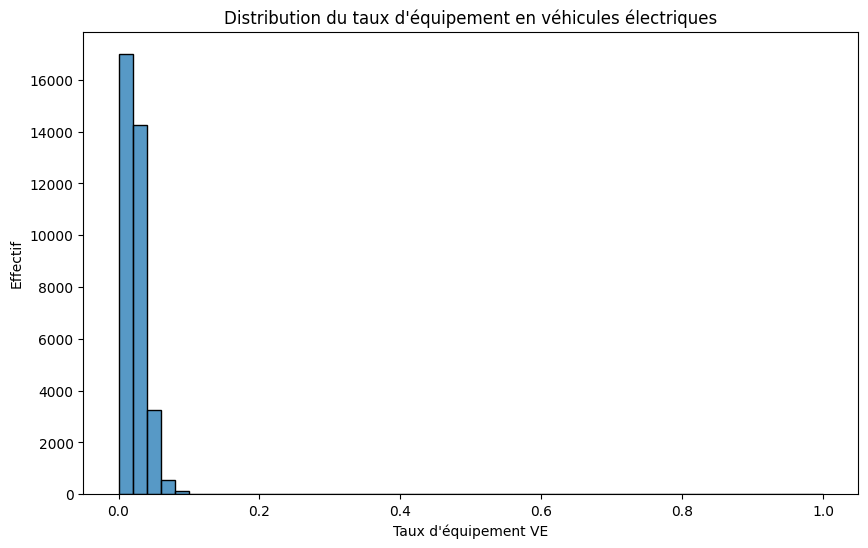

In [35]:
plt.figure(figsize=(10, 6))
sns.histplot(df_imputation[target], bins=50)
plt.title("Distribution du taux d'équipement en véhicules électriques")
plt.xlabel("Taux d'équipement VE")
plt.ylabel("Effectif")
plt.show()

Nous pouvons remarquer que la distribution est très proche de 0, cela montre le nombre important de villes avec un faible taux de voiture électrique

Nous avons effectué une boite à moustaches qui met en évidence une distribution fortement asymétrique à droite du taux d’équipement en véhicules électriques. Pour palier à ceci,  une transformation logarithmique de la variable cible sera envisagée lors de la modélisation.

## Analyse des variables explicatives

L'analyse descriptive montre des distributions asymétriques avec des valeurs manquuantes pour certaines variables, ce qui rend les moyennes peu représentatives. Ceci nous conforte dans l'idée de l'importance d'utiliser des ratios et une fonction logarithmique pour palier aux problèmes rencontrés 

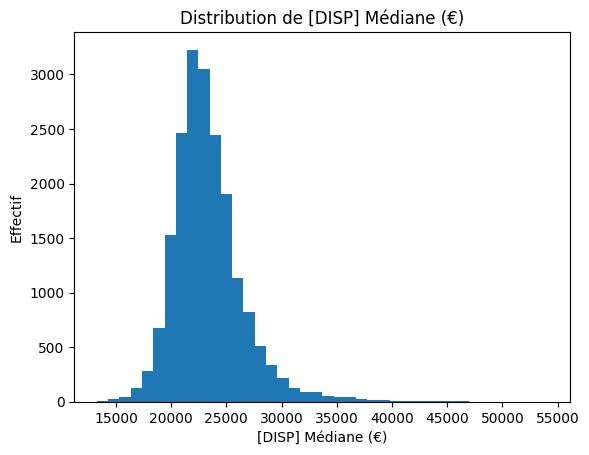

In [36]:
plt.figure()
plt.hist(df_imputation["[DISP] Médiane (€)"].dropna(), bins=40)
plt.title(f"Distribution de {"[DISP] Médiane (€)"}")
plt.xlabel("[DISP] Médiane (€)")
plt.ylabel("Effectif")
plt.show()

La variable de revenu médian présente une distribution relativement équilibrée, centrée autour de 23 000 €, avec une légère asymétrie à droite traduisant la présence de communes plus aisées. Contrairement aux autres variables, elle ne souffre ni d’une forte concentration en zéros ni d’extrêmes marqués, ce qui en fait une variable stable et potentiellement informative pour la modélisation.

## Analyses bivariées

Variables numériques vs cible

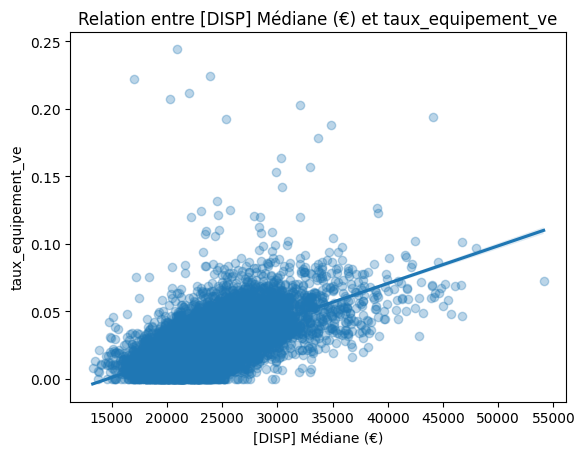

In [37]:
plt.figure()
sns.regplot(x=df_imputation["[DISP] Médiane (€)"], y=df_imputation[target], scatter_kws={"alpha": 0.3})
plt.title(f"Relation entre {"[DISP] Médiane (€)"} et {target}")
plt.show()

On observe une relation positive entre le revenu médian et le taux d’équipement en véhicules électriques : plus une commune est aisée, plus le taux d’équipement tend à être élevé.

## Corrélations

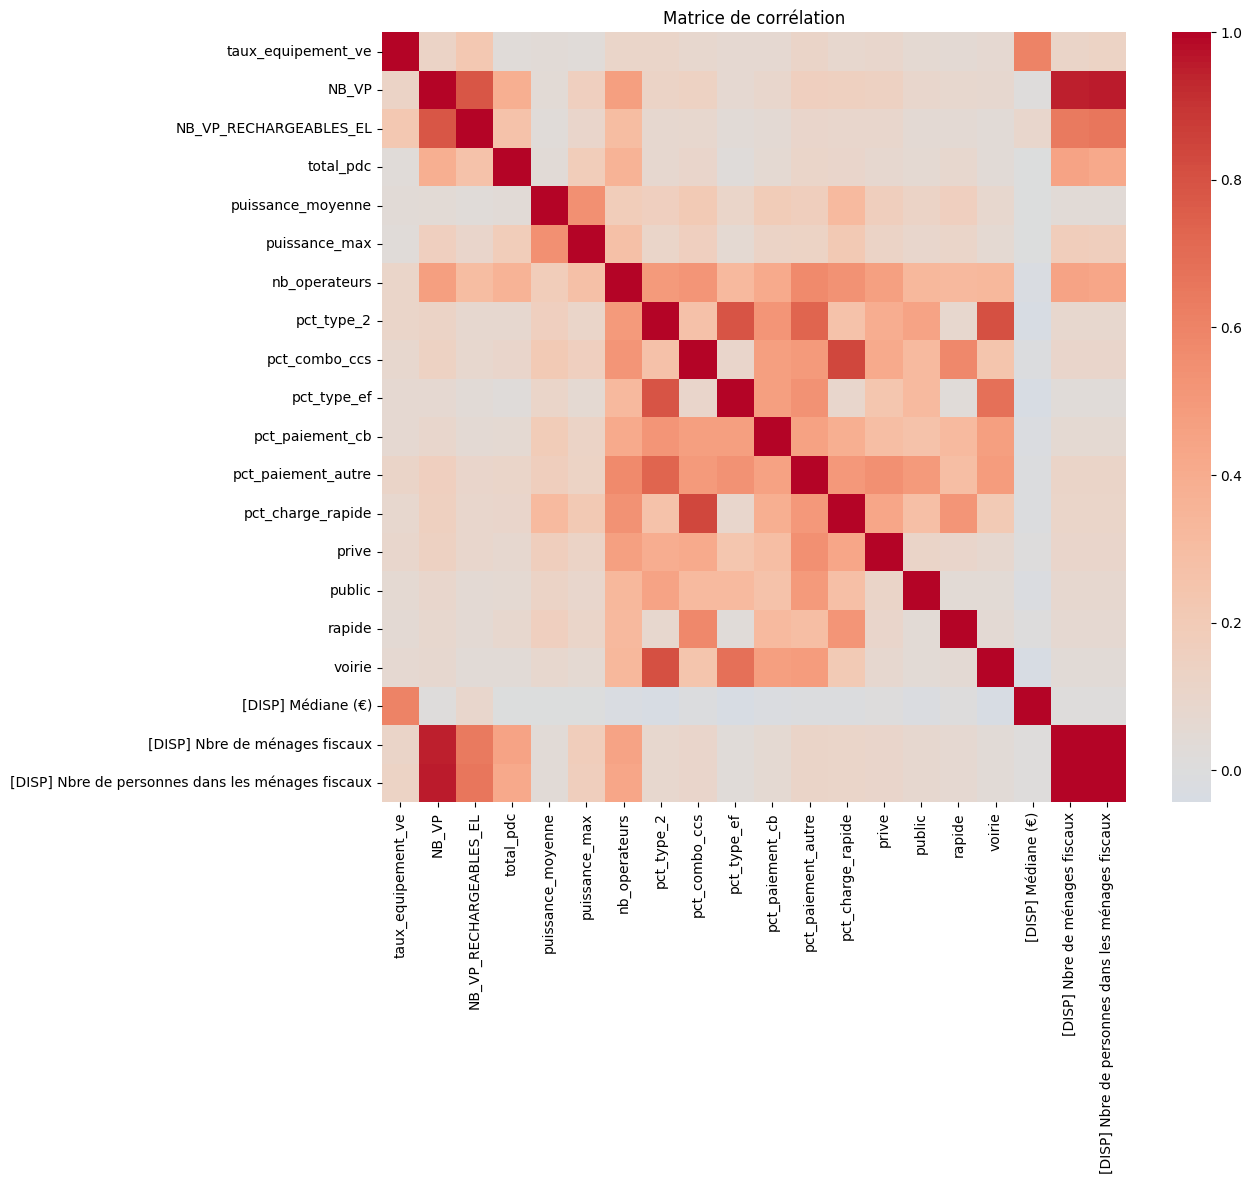

In [38]:
cols_to_exclude = ["CODGEO", "Libellé géographique", target]

num_cols = [
    col for col in df_imputation.select_dtypes(include=["number"]).columns
    if col not in cols_to_exclude
]
corr = df_imputation[[target] + num_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Matrice de corrélation")
plt.show()

Ce que nous enseigne la matrice de corrélation :
Le taux VE dépend surtout :
- de la richesse ( plus une ville est riche, plus elle semble compter des VE )
- du volume de véhicules ( Plus une ville compte de véhicules, plus elle semble compter des VE )

Les infrastructures semblent peu expliquer directement, elles suivent la demande.

Des variables sont redondentes donc peuvent être éliminées.

Corrélations avec la cible :

In [39]:
corr_target = corr[target].sort_values(ascending=False)
display(corr_target)

taux_equipement_ve                                   1.000000
[DISP] Médiane (€)                                   0.603772
NB_VP_RECHARGEABLES_EL                               0.222431
[DISP] Nbre de personnes dans les ménages fiscaux    0.128367
NB_VP                                                0.123340
[DISP] Nbre de ménages fiscaux                       0.116822
pct_paiement_autre                                   0.116803
nb_operateurs                                        0.108069
pct_type_2                                           0.105197
prive                                                0.089406
pct_combo_ccs                                        0.080660
pct_charge_rapide                                    0.078969
voirie                                               0.070126
pct_paiement_cb                                      0.066408
pct_type_ef                                          0.065548
public                                               0.059884
rapide  

Nous pouvons voir une forme d'explication avec certains groupes de variables comme celles socio démographiques. Un tri va être opéré pour une meilleure lisibilité.

In [40]:
vars_to_drop = [
    "NB_VP",
    "NB_VP_RECHARGEABLES_EL",
    "[DISP] Nbre de ménages fiscaux",
    "pct_type_2",
    "pct_type_ef",
    "part_charge_rapide"
]

df_clean = df_imputation.drop(columns=vars_to_drop, errors="ignore")

In [41]:
df_clean

,CODGEO,taux_equipement_ve,total_pdc,puissance_moyenne,puissance_max,nb_operateurs,pct_combo_ccs,pct_paiement_cb,pct_paiement_autre,pct_charge_rapide,top_operateur,prive,public,rapide,voirie,Libellé géographique,[DISP] Médiane (€),[DISP] Nbre de personnes dans les ménages fiscaux
0,1002,0.017483,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Aucun,0.0,0.0,0.0,0.0,NaN,NaN,NaN
1,1004,0.032214,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Aucun,0.0,0.0,0.0,0.0,NaN,NaN,NaN
2,1005,0.029488,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Aucun,0.0,0.0,0.0,0.0,NaN,NaN,NaN
3,1007,0.032400,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Aucun,0.0,0.0,0.0,0.0,NaN,NaN,NaN
4,1009,0.022075,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Aucun,0.0,0.0,0.0,0.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35201,97612,0.003136,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Aucun,0.0,0.0,0.0,0.0,NaN,NaN,NaN
35202,97615,0.001649,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Aucun,0.0,0.0,0.0,0.0,NaN,NaN,NaN
35203,97699,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Aucun,0.0,0.0,0.0,0.0,NaN,NaN,NaN
35204,97801,0.042105,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Aucun,0.0,0.0,0.0,0.0,NaN,NaN,NaN


In [42]:
df_clean.to_csv("data/df_clean.csv", index=False)

Nous avons effectué un tri des variables à la suite des corrélations, ainsi nous avons une nouvelle base de données de 18 variables : "df_clean"

Désormais nous allons effectuer un premier modèle, une régression Lasso pour pouvoir aussi faire une sélection de variables supplémentaire.

A faire :
- analyse de la variable cible
- analyse descriptive des variables explicatives (univariées + bivariées)
- étude des corrélations
- nouveau tri des variables à la suite des analyses
- vérifier que le format des variables est correcte pour la modélisation.

## 8. Modélisation

Nous cherchons à prédire la variable taux_equipement_ve.

Approche 1 : Régression Lasso
Le modèle Lasso est idéal pour l'interprétabilité. Il permet de voir quelles variables "pèsent" réellement dans la décision d'achat d'un véhicule électrique.

Approche 2 : XGBoost
Ce modèle non-linéaire permet ...

Nos variables pour la modélisation sont les suivantes :

In [43]:
df_clean.columns

Index(['CODGEO', 'taux_equipement_ve', 'total_pdc', 'puissance_moyenne',
       'puissance_max', 'nb_operateurs', 'pct_combo_ccs', 'pct_paiement_cb',
       'pct_paiement_autre', 'pct_charge_rapide', 'top_operateur', 'prive',
       'public', 'rapide', 'voirie', 'Libellé géographique',
       '[DISP] Médiane (€)',
       '[DISP] Nbre de personnes dans les ménages fiscaux'],
      dtype='object')

Lors de notre modélisation, nous avons été contraints de retirer des variables géographiques, alors nous avons souhaité ajouter les départements, cependant beaucoup de problèmes se présentaient. Nous avons alors décidé de regarder avec les régions. Tout ceci est détaillé dans le fichier : "regression_lasso.ipynb".

In [44]:
results = regression_lasso_depuis_notebook(df_clean, target)

In [45]:
selected_features = results["selected_features"]
removed_features = results["removed_features"]
df_selected = results["df_selected"]

Voici les variables annulées

In [46]:
print(removed_features)

['puissance_max', 'pct_combo_ccs', 'pct_charge_rapide', 'region_Auvergne-Rhone-Alpes', 'region_Occitanie']


La nouvelle base ed données avec les variables sélectionnées plus les rigions ajoutées.

In [47]:
df_selected

,total_pdc,puissance_moyenne,nb_operateurs,pct_paiement_cb,pct_paiement_autre,prive,public,rapide,voirie,[DISP] Médiane (€),...,region_Grand Est,region_Hauts-de-France,region_Ile-de-France,region_Normandie,region_Nouvelle-Aquitaine,region_Outre-Mer,region_Pays de la Loire,region_Provence-Alpes-Cote d'Azur,revenu_manquant,population_manquante
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22880.0,...,1,0,0,0,0,0,0,0,1,1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22880.0,...,1,0,0,0,0,0,0,0,1,1
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22880.0,...,1,0,0,0,0,0,0,0,1,1
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22880.0,...,1,0,0,0,0,0,0,0,1,1
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22880.0,...,1,0,0,0,0,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35201,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22880.0,...,0,0,0,0,0,1,0,0,1,1
35202,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22880.0,...,0,0,0,0,0,1,0,0,1,1
35203,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22880.0,...,0,0,0,0,0,1,0,0,1,1
35204,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22880.0,...,0,0,0,0,0,0,0,0,1,1


La régression Lasso met en évidence le rôle prépondérant du revenu médian dans l’explication du taux d’équipement en véhicules électriques.
Les variables liées à l’infrastructure de recharge apparaissent également comme significatives, bien que leur impact reste secondaire.
L’introduction d’une dimension géographique via les régions permet de mettre en évidence des disparités territoriales marquées, certaines régions présentant un niveau d’équipement plus élevé que d’autres, toutes choses égales par ailleurs.
Enfin, la variable indicatrice de données manquantes sur le revenu met en évidence un effet structurel, suggérant que les territoires moins bien documentés ou moins développés présentent un retard dans l’adoption des véhicules électriques.
Les véhicules électriques sont d’abord un phénomène économique, puis infrastructurel, et enfin territorial.

Désormais nous allons implémenter un second modèle et non linéaire cette fois-ci, une random forest pour tenter d'expliquer davantage les liens potentiels.

### Random Forest

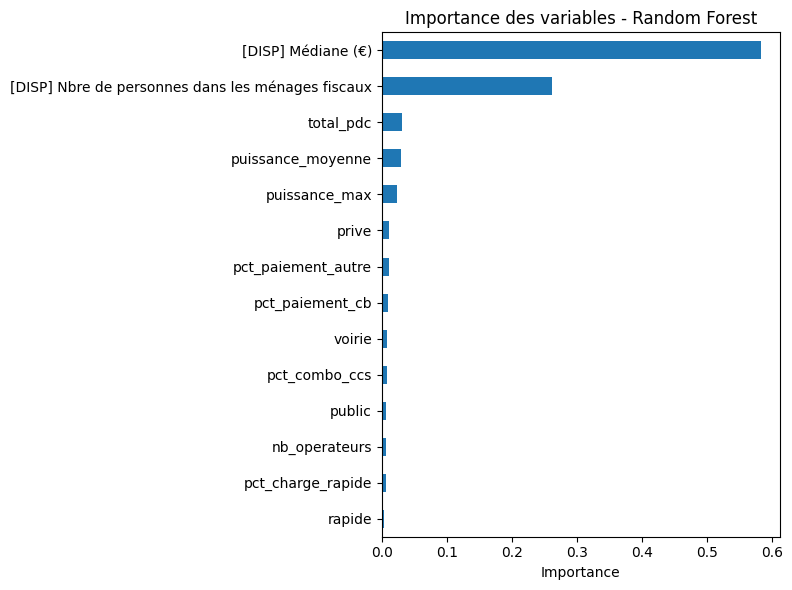

SHAP non calculé : No module named 'shap'


In [48]:
random_forest = random_forest_depuis_notebook(
    df_clean,
    target="taux_equipement_ve",
    compute_shap=True,
    plot_shap=True)

Voici les graphiques car le modèle peut prendre du temps à se finir.
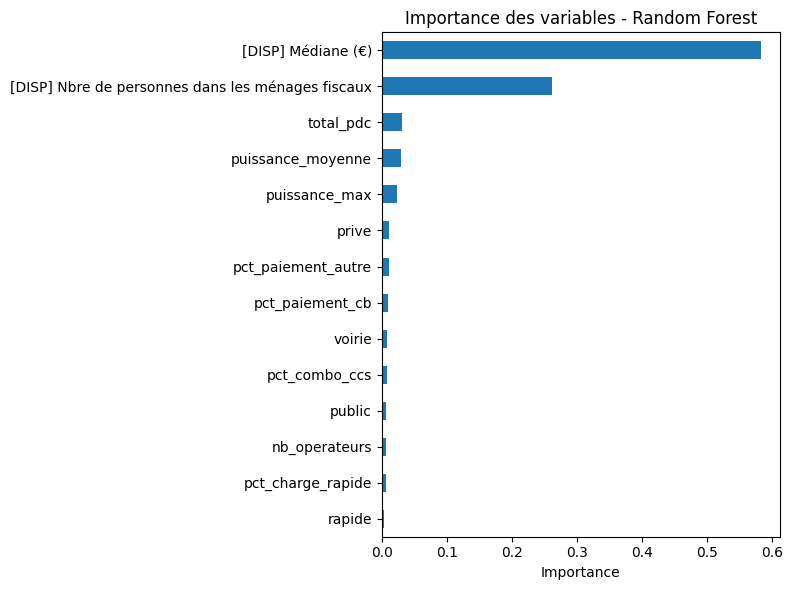
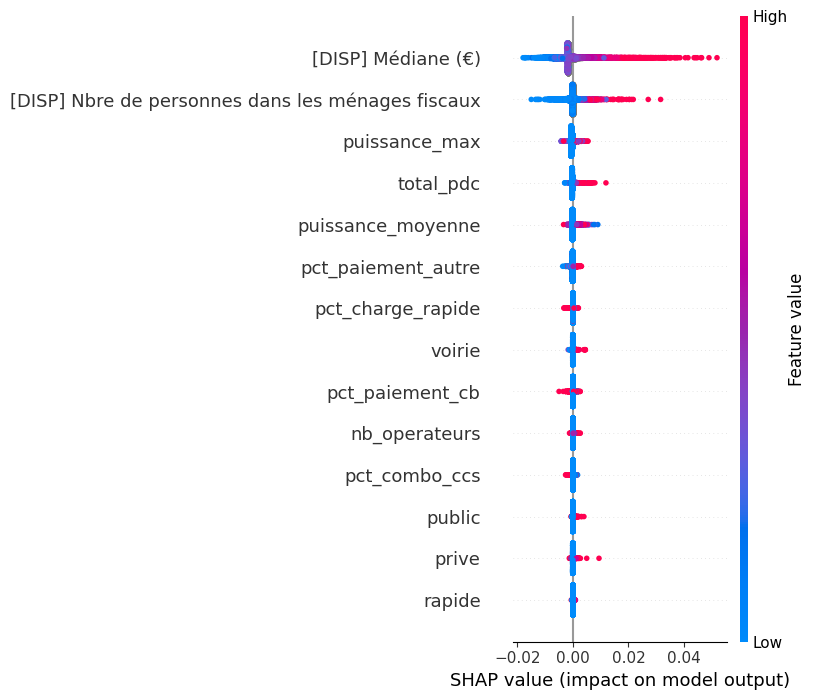
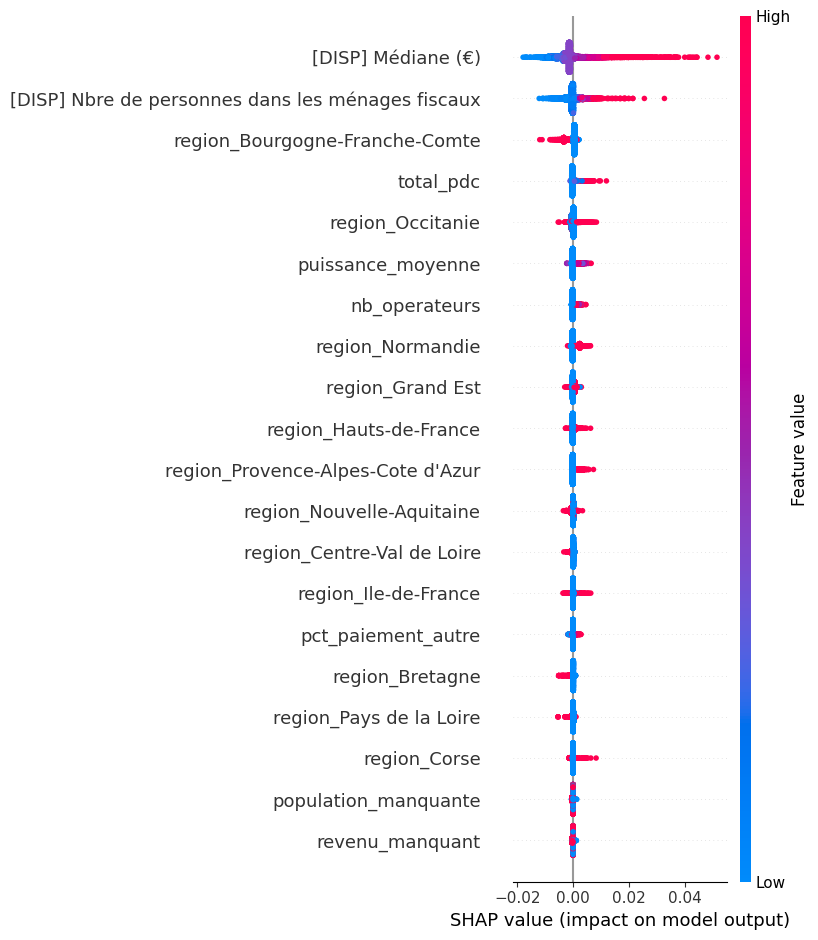

Ce graphique SHAP permet d’interpréter le modèle de Random Forest en montrant l’impact de chaque variable sur la prédiction du taux d’équipement en véhicules électriques. Chaque point correspond à une observation, et sa position indique si la variable augmente ou diminue la prédiction.

Le revenu médian apparaît comme le facteur dominant : des valeurs élevées sont fortement associées à un taux d’équipement plus élevé. La taille de la population joue également un rôle positif, mais plus modéré.

Les variables d’infrastructure ont un impact plus limité, suggérant qu’elles sont secondaires. Enfin, les effets régionaux montrent des disparités territoriales, certaines régions étant plus favorables que d’autres à l’adoption des véhicules électriques.

Globalement, ces résultats confirment que l’adoption des véhicules électriques est avant tout liée au niveau de richesse, puis à des effets géographiques, l’infrastructure jouant un rôle complémentaire.

## 9. Analyse des résultats

Ce projet visait à expliquer et modéliser le niveau d’équipement en infrastructures de recharge pour véhicules électriques à partir de variables socio-économiques, territoriales et techniques.

L’analyse exploratoire ainsi que les modèles mis en œuvre (régression pénalisée, modèles d’ensemble) montrent que certaines variables jouent un rôle structurant, en particulier le niveau de revenu et la taille des populations, qui apparaissent comme les principaux déterminants de l’équipement. Ces résultats sont cohérents avec une logique économique et territoriale : les zones plus riches et plus densément peuplées tendent à être mieux équipées.

Cependant, les performances globales des modèles restent limitées et les analyses d’interprétabilité (notamment via les valeurs SHAP) mettent en évidence une faible contribution marginale des variables explicatives. Cela suggère que le phénomène étudié est seulement partiellement capturé par les données disponibles.

Ainsi, le déploiement des infrastructures de recharge semble largement dépendre de facteurs exogènes non observés dans la base, tels que les politiques publiques locales, les stratégies d’investissement des opérateurs ou encore des contraintes d’aménagement du territoire.

En ce sens, ce travail met en évidence les limites d’une approche purement statistique sur ce type de problématique, tout en confirmant l’existence de tendances structurelles. Il ouvre également des perspectives d’amélioration, notamment via l’intégration de variables institutionnelles ou géographiques plus fines.